# 09. Predict accessibility with a trained model

The [training section](../model_training/06_train_borzoi_lora.ipynb) fit a cell-state-conditioned
Bolero model on **ChromiumPBMC**. This page runs that model **forward**: given a DNA window and a
cell state, it predicts base-resolution ATAC accessibility. The goal here is not to reproduce a
paper figure — it is to show **what you feed the prediction task and what it writes out.**

**In / out.**

- **Inputs** — a trained checkpoint + its train config (from notebook 06), the 32 bp parquet store
  and coverage-matched pseudobulks (from notebooks [04](../meta_cell_adata_and_parquet/04_parquet_dataset.ipynb)–[05](../meta_cell_adata_and_parquet/05_pseudobulk_and_reference.ipynb)),
  the reference bigWig, and a peak BED. You choose **which genomic regions** and **which cell states
  (pseudobulks)** to predict.
- **Outputs** — an `output_dir/` of per-batch predictions plus aggregated files: a per-base 32 bp
  accessibility track per region×cell-state, a per-peak accessibility value, and summary metrics.

> **This notebook runs in place** and reads the artifacts built earlier in the series via relative
> paths. It uses `BorzoiSignalPredictor` — the raw-config predictor — so it is fully self-contained
> (no lab data lake needed). The variant-effect and attribution pages that follow use the
> `bolerodata` model zoo instead.

## Setup

In [1]:
import os
from pathlib import Path

import anndata as ad
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bolero import init
from bolero.tl.predict.predictor_borzoi import BorzoiSignalPredictor

init(num_cpus=16, object_store_memory_gb=48)

2026-07-13 19:06:47,200	INFO worker.py:1781 -- Started a local Ray instance.


## Configure the run

Everything the predictor needs is a flat config dict of paths. We name the two inputs from the
previous sections (the trained model, and the data it was trained on).

In [2]:
# --- Configuration --------------------------------------------------------------
MODEL_DIR = Path("../model_training/model")        # produced by notebook 06
DATA_DIR = Path("../meta_cell_adata_and_parquet")  # produced by notebooks 04-05

SAVENAME = "ChromiumPBMC-atac-signal-fold0"
CHECKPOINT = MODEL_DIR / f"{SAVENAME}.lora.best_checkpoint.pt"   # trained LoRA weights (nb 06)
TRAIN_CONFIG = MODEL_DIR / f"{SAVENAME}.config.json"            # the config nb 06 saved

PARQUET_DIR = DATA_DIR / "ChromiumPBMC-MetaCell-32bp"                  # page 04
PSEUDOBULK_RECORDS = DATA_DIR / "pseudobulk_records_and_cond.cov5000000.joblib"  # page 05
REFERENCE_BW = DATA_DIR / "reference.bw"                              # page 05
PEAK_H5AD = DATA_DIR / "metacell.peak_count.h5ad"                     # page 03

assert CHECKPOINT.exists(), "run notebook 06 first to train the model"
assert PARQUET_DIR.exists() and PSEUDOBULK_RECORDS.exists(), "run notebooks 04-05 first" 

## The two inputs you choose: regions and cell states

A prediction is made for a **(region, cell state)** pair. So there are two things to prepare.

**Cell states = pseudobulk records.** Each record carries the 30-dim cell-state embedding that
conditions the model (plus a coverage scale and the meta-cells it pools). `designs` selects which
ones to predict — here a small subset so the demo is quick.

In [3]:
records = joblib.load(PSEUDOBULK_RECORDS)["pseudobulk_records"]

example = records["group0-pseudobulk0"]
print("a pseudobulk record holds:", list(example))
print("  embedding shape :", np.asarray(example["embedding"]).shape, "(the cell-state vector)")
print("  cov_scale       :", example["cov_scale"])

# predict a small subset of cell states so the demo runs in a minute or two
DESIGNS = sorted(records)[:8]
print("\npredicting", len(DESIGNS), "cell states:", DESIGNS)

a pseudobulk record holds: ['cluster_ids', 'n_frags', 'cov_scale', 'embedding', 'sample_weight']
  embedding shape : (30,) (the cell-state vector)
  cov_scale       : {'ChromiumPBMC.MetaCell': np.float32(0.03238462)}

predicting 8 cell states: ['group0-pseudobulk0', 'group0-pseudobulk1', 'group0-pseudobulk2', 'group0-pseudobulk3', 'group1-pseudobulk0', 'group1-pseudobulk1', 'group1-pseudobulk10', 'group1-pseudobulk11']


**Regions.** `regions="test_regions"` uses the held-out chromosomes of fold 0 (the split the
model was trained with, read from `fold_split_id` in the train config). To predict on your own loci
instead, pass a list of `"chr:start-end"` windows or a DataFrame — each is centered to the model's
524,288 bp input window. We keep just a handful of regions here with `downsample_regions`.

**Peaks.** The model outputs a base-resolution track; a per-peak accessibility value is the track
summed over each ATAC peak. The peak coordinates are simply the `var` of the meta-cell peak AnnData
— already in BED form — which we write to a local file for the predictor's `peak_path`.

In [4]:
peak_var = ad.read_h5ad(PEAK_H5AD, backed="r").var
peak_bed = peak_var[["Chromosome", "Start", "End", "Name"]]
PEAK_BED = Path("chrompbmc_peaks.bed")
peak_bed.to_csv(PEAK_BED, sep="\t", header=False, index=False)
print("wrote", f"{len(peak_bed):,}", "peaks to", PEAK_BED)
peak_bed.head(3)

wrote 227,031 peaks to chrompbmc_peaks.bed


,Chromosome,Start,End,Name
Name,,,,
chr1:816081-816581,chr1,816081,816581,chr1:816081-816581
chr1:817090-817590,chr1,817090,817590,chr1:817090-817590
chr1:821042-821542,chr1,821042,821542,chr1:821042-821542


## Build the predictor

`BorzoiSignalPredictor(config)` loads the checkpoint, rebuilds the LoRA model, and assembles the
data manager (parquet + reference bigWig + pseudobulk embeddings) — all from the config below. The
model loads lazily, so this is cheap; the GPU work starts when we call the task.

In [5]:
config = {
    "checkpoint_path": str(CHECKPOINT),
    "train_config": str(TRAIN_CONFIG),
    "genome": "hg38",
    "dataset_path": str(PARQUET_DIR),
    "pseudobulk_records_path": str(PSEUDOBULK_RECORDS),
    "bigwig_paths": {"reference": str(REFERENCE_BW)},   # reference signal for the signal model
    "peak_path": str(PEAK_BED),
    "designs": DESIGNS,                                 # which cell states to predict
    "nosignal": False,                                  # True -> DNA-only (ignore reference signal)
}
predictor = BorzoiSignalPredictor(config)
predictor.pseudobulk_manager

PseudobulkRecordManager(16 records)

## Run the prediction task

`prediction_task` streams the chosen regions through the model for every selected cell state,
extracts the per-peak signal, scores it against the measured data, and writes everything to
`output_dir`.

In [6]:
OUTPUT_DIR = "prediction_task_output"
predictor.prediction_task(
    output_dir=OUTPUT_DIR,
    regions="test_regions",   # fold-0 held-out windows; or pass your own list/DataFrame
    downsample_regions=8,     # a handful of windows so the demo is quick
    downsample_seed=0,
    batch_size=4,
    save_keys=[
        "__ytrue__:peak:cond1",   # measured per-peak accessibility
        "__ypred__:peak:cond1",   # predicted per-peak accessibility
        "region",
        "pseudobulk_ids",
        "peak",
    ],
    save_first_batch=True,        # also dump the full first batch (incl. base-res tracks) for a look
)

Saving batches to /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/prediction_task_output/batch
Saving stats to /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/prediction_task_output/summary_stats.joblib.gz
Using temporary directory /tmp/tmp5vm1xu1c
0 regions has finished in /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/prediction_task_output/batch
8 regions to compute
Data loader batch size 16


Loading base model weights from: /home/hanliu/data/wmb/model/Borzoi/flashzoi_checkpoints/fold_0.renamed.pt


Condition embedding is not used.


Model does not have gene_count_output_head, skip
Loading checkpoint from ../model_training/model/ChromiumPBMC-atac-signal-fold0.lora.best_checkpoint.pt


Dataloader Batch Schema:
- ChromiumPBMC.MetaCell:cov_scale: <class 'torch.Tensor'> torch.Size([16]) torch.float32 cuda:0
- __conditionemb__: <class 'torch.Tensor'> torch.Size([16, 1, 0]) torch.float32 cuda:0
- __conditionemb__:cond0: <class 'torch.Tensor'> torch.Size([8, 1, 0]) torch.float32 cuda:0
- __conditionemb__:cond1: <class 'torch.Tensor'> torch.Size([8, 1, 0]) torch.float32 cuda:0
- __conditionemb__:delta: <class 'torch.Tensor'> torch.Size([8, 1, 0]) torch.float32 cuda:0
- __dna__: <class 'torch.Tensor'> torch.Size([8, 4, 524288]) torch.uint8 cuda:0
- __embedding__: <class 'torch.Tensor'> torch.Size([16, 60]) torch.float32 cuda:0
- __embedding__:cond0: <class 'torch.Tensor'> torch.Size([8, 60]) torch.float32 cuda:0
- __embedding__:cond1: <class 'torch.Tensor'> torch.Size([8, 60]) torch.float32 cuda:0
- __embedding__:delta: <class 'torch.Tensor'> torch.Size([8, 60]) torch.float32 cuda:0
- __ypred__:cond1: <class 'torch.Tensor'> torch.Size([8, 8, 16352]) torch.float32 cuda:0
- __

Total time: 5.85s
Inference time: 3.98s or 3.976s per batch
Callback time: 0.22s or 0.219s per batch
(total 1 batches)

Saved Batch Schema:
- __ypred__:peak:cond1: <class 'numpy.ndarray'> (8, 598) float32
- __ytrue__:peak:cond1: <class 'numpy.ndarray'> (8, 598) float32
- peak: <class 'pandas.core.frame.DataFrame'> (598, 6)
- pseudobulk_ids: <class 'numpy.ndarray'> (16,) <U24
- region: <class 'numpy.ndarray'> (8,) <U25

Final Stats Batch Schema:
- condition_pairs: <class 'numpy.ndarray'> (8, 2) <U8
- peak: <class 'pandas.core.frame.DataFrame'> (598, 6)
- peak_pearsonr: <class 'numpy.ndarray'> (8,) float32
- peak_r2: <class 'numpy.ndarray'> (8,) float32
- pseudobulk_ids: <class 'numpy.ndarray'> (16,) <U24
- region: <class 'numpy.ndarray'> (8,) <U25

Removed temporary files in /tmp/tmp5vm1xu1c
1 batches in /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/prediction_task_output


## What the task wrote

Everything lands in `output_dir`. Two files summarize the run:

- **`summary_stats.joblib.gz`** — accuracy metrics plus bookkeeping: `peak_pearsonr` and `peak_r2`
  are the Pearson r and R² between measured and predicted **per-peak accessibility**, computed across
  peaks for each predicted cell state (one value per pseudobulk); `region`, `pseudobulk_ids`,
  `condition_pairs` and the `peak` table record what was predicted.
- **`first_batch.joblib.gz`** — the full first batch we asked to keep, including the base-resolution
  tracks `__ytrue__:cond1` / `__ypred__:cond1` (shape `n_region × n_pseudobulk × n_bins`).

Per-batch predictions are under `batch/`; the aggregated per-peak tables are `pred_peak_data.feather`
(predicted) and `true_peak_data.feather` (measured), one row per peak × cell state.

In [7]:
print("output files:", sorted(os.listdir(OUTPUT_DIR)))
print()
stats = joblib.load(f"{OUTPUT_DIR}/summary_stats.joblib.gz")
for k, v in stats.items():
    shape = getattr(v, "shape", None)
    print(f"  {k:18s} {type(v).__name__:12s} {shape if shape is not None else ''}")

output files: ['batch', 'config.joblib.gz', 'first_batch.joblib.gz', 'pred_peak_data.feather', 'summary_stats.joblib.gz', 'true_peak_data.feather']

  region             ndarray      (8,)
  pseudobulk_ids     ndarray      (16,)
  condition_pairs    ndarray      (8, 2)
  peak               DataFrame    (598, 6)
  peak_pearsonr      ndarray      (8,)
  peak_r2            ndarray      (8,)


In [8]:
# The aggregated per-peak table: one row per (peak, cell state) with measured vs predicted signal.
peak_feather = f"{OUTPUT_DIR}/pred_peak_data.feather"
if os.path.exists(peak_feather):
    pred_peaks = pd.read_feather(peak_feather)
    print("pred_peak_data.feather:", pred_peaks.shape)
    display(pred_peaks.head())
else:
    print("no pred_peak_data.feather (no peaks fell inside the sampled regions)")

pred_peak_data.feather: (598, 8)


,group0-pseudobulk0,group0-pseudobulk1,group0-pseudobulk2,group0-pseudobulk3,group1-pseudobulk0,group1-pseudobulk1,group1-pseudobulk10,group1-pseudobulk11
chr10:119381862-119382362,1.949854,1.816514,2.223076,1.661757,3.430417,2.699487,3.305125,1.937560
chr10:119383408-119383908,6.485242,6.536098,6.507982,6.440866,13.341636,11.530752,14.124143,7.704761
chr10:119395227-119395727,29.305195,29.929186,26.965391,31.392242,50.267532,50.401802,53.562763,42.147087
chr10:119396315-119396815,5.093325,5.136376,5.099528,5.078576,9.804277,8.366509,10.122571,6.087479
chr10:119401642-119402142,8.819023,8.701636,8.756453,8.727706,20.547596,18.130222,21.535221,12.798142


## A quick look at one prediction

The base-resolution output is what the model actually produces. Here is one predicted ATAC track
overlaid on the measured track for a single region × cell state — smoothed for legibility. (This
demo model was trained for only a few minutes in notebook 06, so treat the agreement as
illustrative of the *output format*, not of accuracy.)

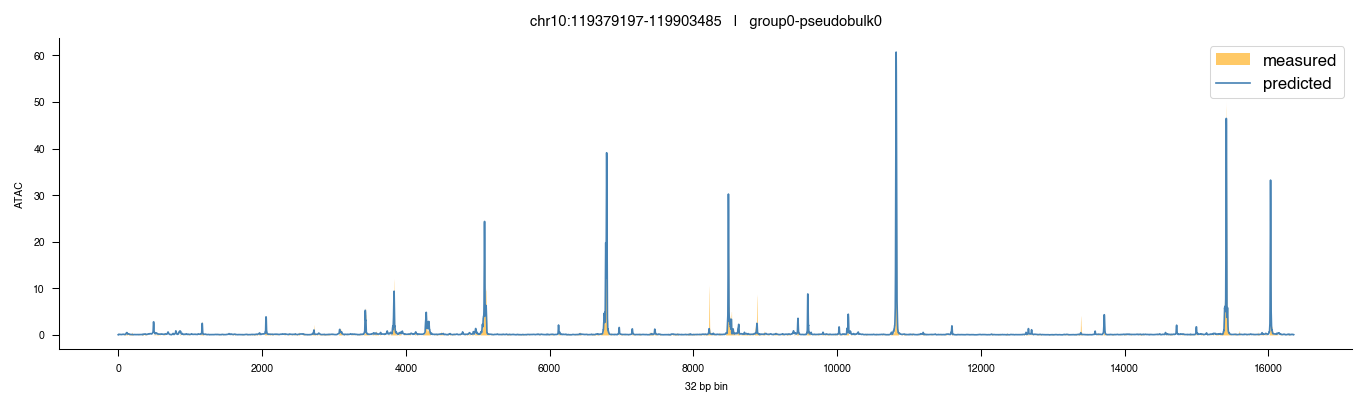

In [9]:
def to_np(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)

batch = joblib.load(f"{OUTPUT_DIR}/first_batch.joblib.gz")
ytrue = to_np(batch["__ytrue__:cond1"])   # (n_region, n_pseudobulk, n_bins)
ypred = to_np(batch["__ypred__:cond1"])

# map the batch's internal (paired) ids back to the cell-state names for a readable label
config = joblib.load(f"{OUTPUT_DIR}/config.joblib.gz")
idmap = {k: v.get("__pid__", k) for k, v in config["pseudobulk_records"].items()}
cell_states = pd.Index(batch["pseudobulk_ids"][::2]).map(idmap)
rid, pid = 0, 0                            # first region, first cell state

smooth = lambda y: np.convolve(y, np.ones(8) / 8, mode="same")
fig, ax = plt.subplots(figsize=(9, 2.6), dpi=150, constrained_layout=True)
ax.fill_between(np.arange(ytrue.shape[-1]), smooth(ytrue[rid, pid]), color="orange",
                alpha=0.6, lw=0, label="measured")
ax.plot(smooth(ypred[rid, pid]), color="steelblue", lw=0.8, label="predicted")
ax.set(title=f"{batch['region'][rid]}   |   {cell_states[pid]}", xlabel="32 bp bin", ylabel="ATAC")
ax.legend(fontsize=8)

## Predicting with the full Bolero-10M model

This page used the small single-dataset model from notebook 06 so it stays self-contained. To run
the fully-trained atlas model from the paper instead, load it from the `bolerodata` model zoo — the
task API is identical:

```python
from bolerodata import MODELS

predictor = MODELS["Borzoi10M"].create_predictor()   # resolves checkpoint + data from the data lake
predictor.prediction_task("out", regions="test_regions")
```

(The `create_predictor` route needs the lab data lake; the next two pages use it for variant-effect
and attribution prediction.)

---

You have now run a trained Bolero model forward and seen the shape of its output: a per-base ATAC
track and a per-peak accessibility value for each cell state. The next page uses the same machinery
to score **DNA variants** — predicting the cell-state-specific effect of a SNV on accessibility
([caQTL](10_qtl_task.ipynb)) or expression (eQTL).